## Trabajo Práctico: Redes Neuronales
El objetivo de este trabajo es desarrollar y evaluar modelos basados en redes neuronales,
incorporando técnicas de ablación para entender el impacto de diversas modificaciones en
el proceso de entrenamiento y en la capacidad de generalización del modelo. No se permite
usar librerías de machine learning como scikit-learn o PyTorch, a menos que sea pedido
explícitamente en el enunciado del ejercicio.

### 1. Análisis y Preprocesamiento de Datos
- El dataset que vamos a utilizar es similar a MNIST pero con caracteres japoneses.
- Son imágenes de 28 × 28 con 49 clases posibles.
- Examinar el dataset y visualizar al menos 3 imágenes. 
- Dividir el conjunto de datos en tres subconjuntos: Train, Validation y Test.
- Dividir todos los valores por 255, para que el máximo sea 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('src/')
from preprocessing import *
from plots import *
from models import *

In [2]:
X_images = np.load("data/X_images.npy")
y_images = np.load("data/y_images.npy")

print("Forma de X_images:", X_images.shape)
print("Forma de y_images:", y_images.shape)
print("Número de clases únicas:", len(np.unique(y_images)))

Forma de X_images: (5000, 784)
Forma de y_images: (5000,)
Número de clases únicas: 49


1. Una visión clara de la distribución de clases para detectar posibles desbalances
2. Estadísticas sobre los valores de píxeles para entender las propiedades generales de las imágenes
3. Imágenes "promedio" de cada clase para visualizar sus características distintivas
4. Un análisis de complejidad por clase para ver cuáles pueden ser más difíciles de clasificar
5. Múltiples ejemplos de cada clase para comprender mejor la variabilidad dentro de cada categoría

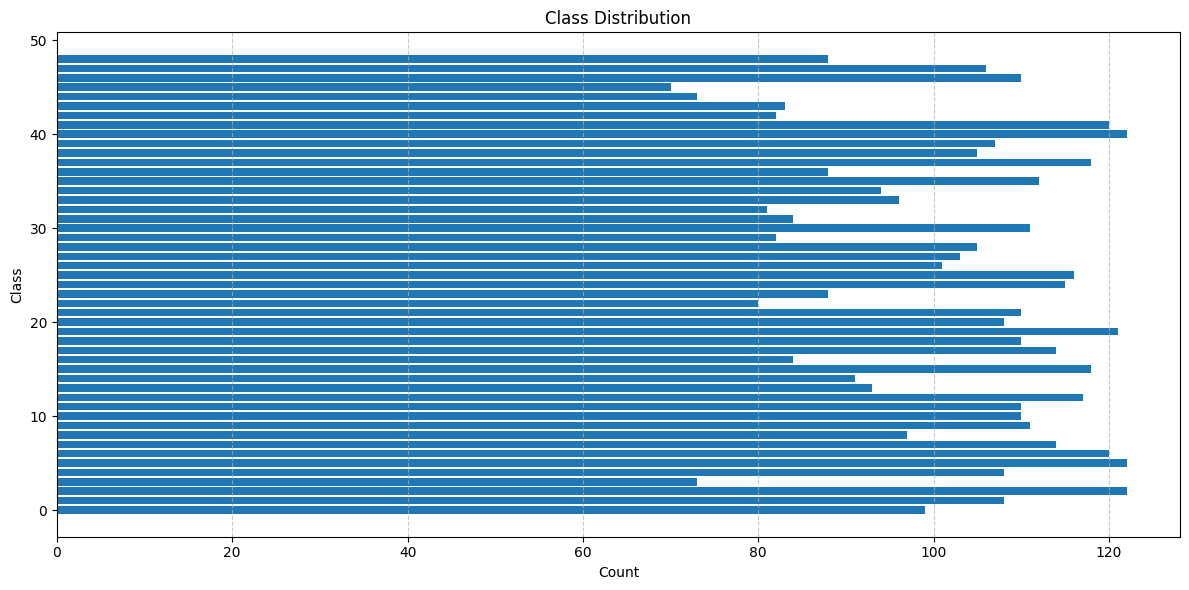

Most common class: 2 with 122 samples
Least common class: 45 with 70 samples
Class imbalance ratio (most common / least common): 1.74


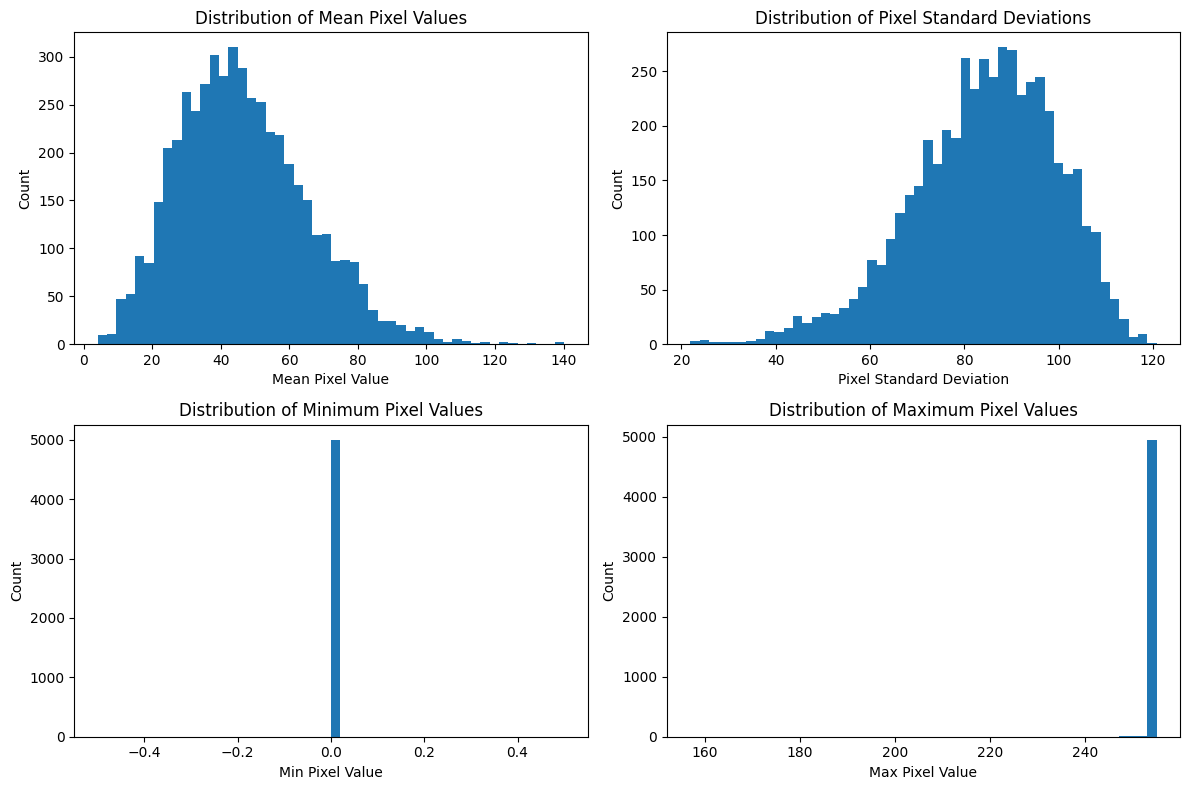

Average mean pixel value: 46.5255
Average pixel standard deviation: 84.1463
Proportion of images with completely black pixels: 1.0000
Proportion of images with completely white pixels: 0.9840


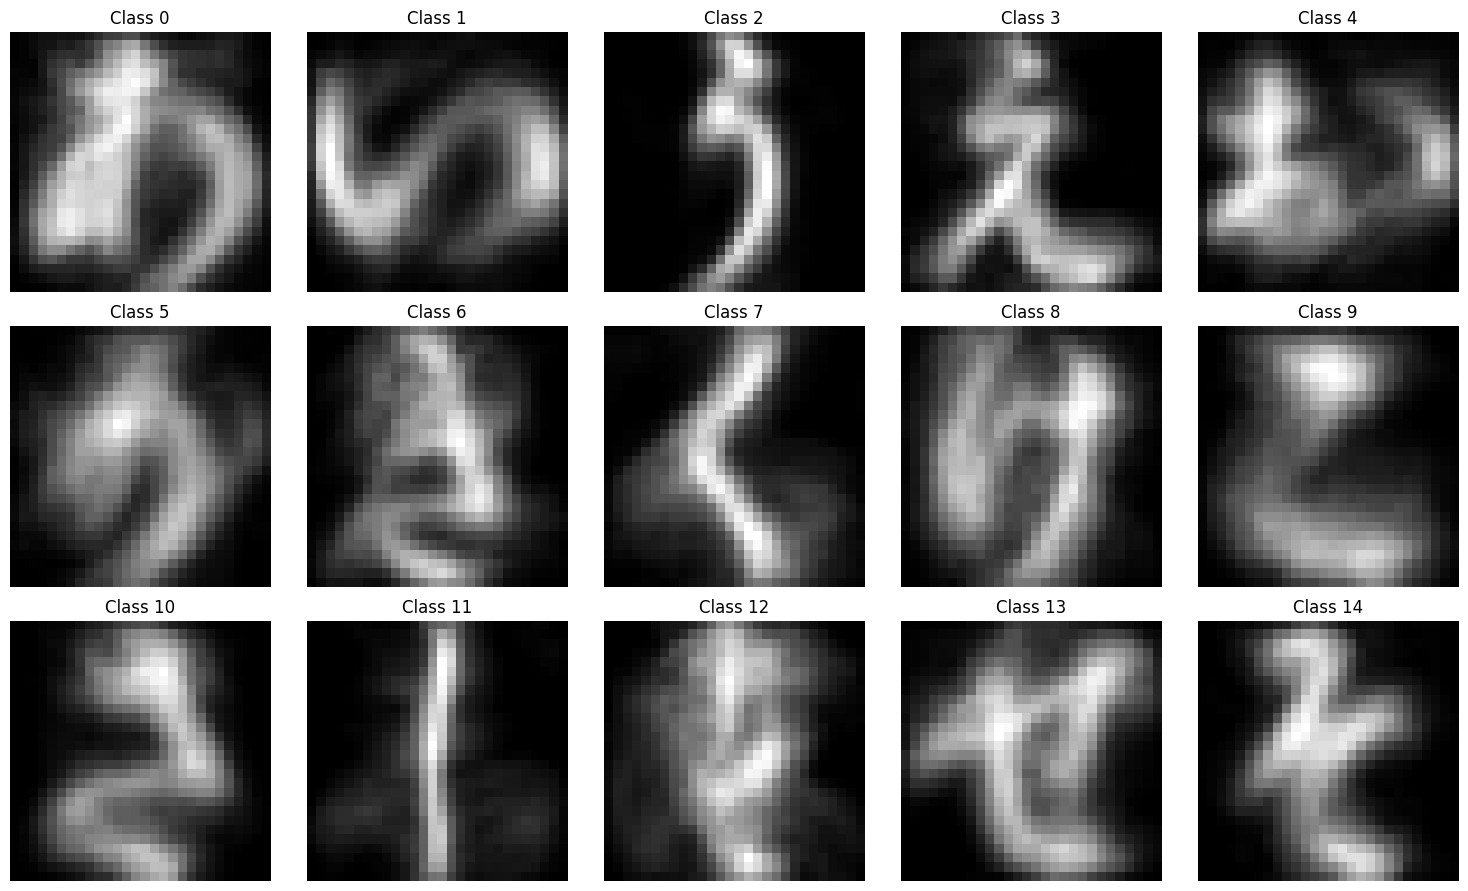

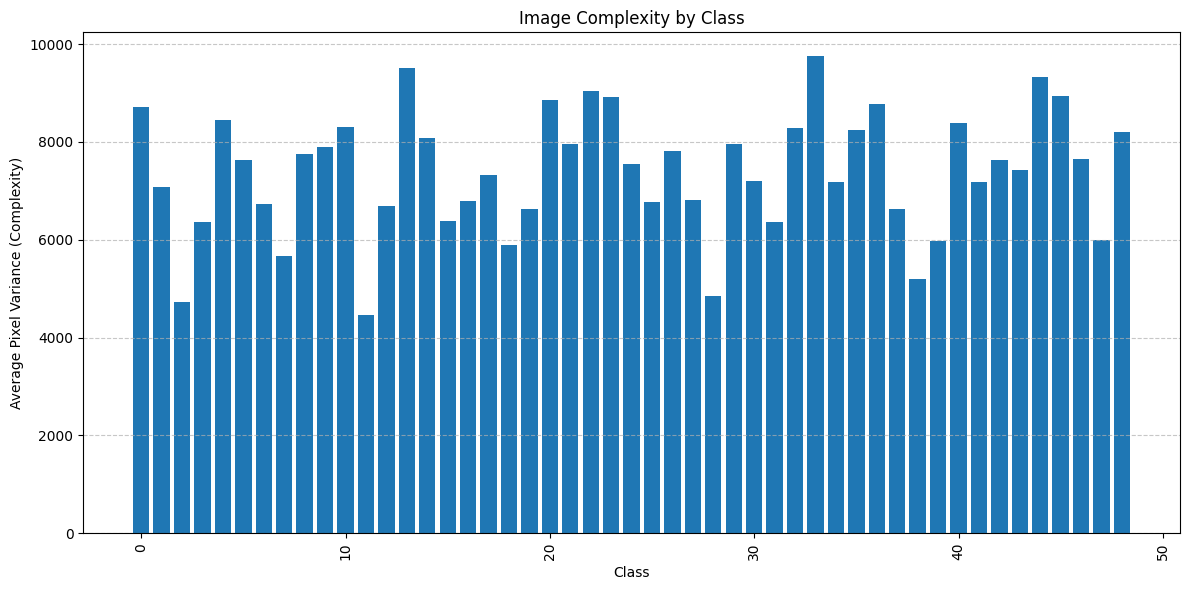

Most complex class: 33 with variance 9754.6709
Least complex class: 11 with variance 4462.4160


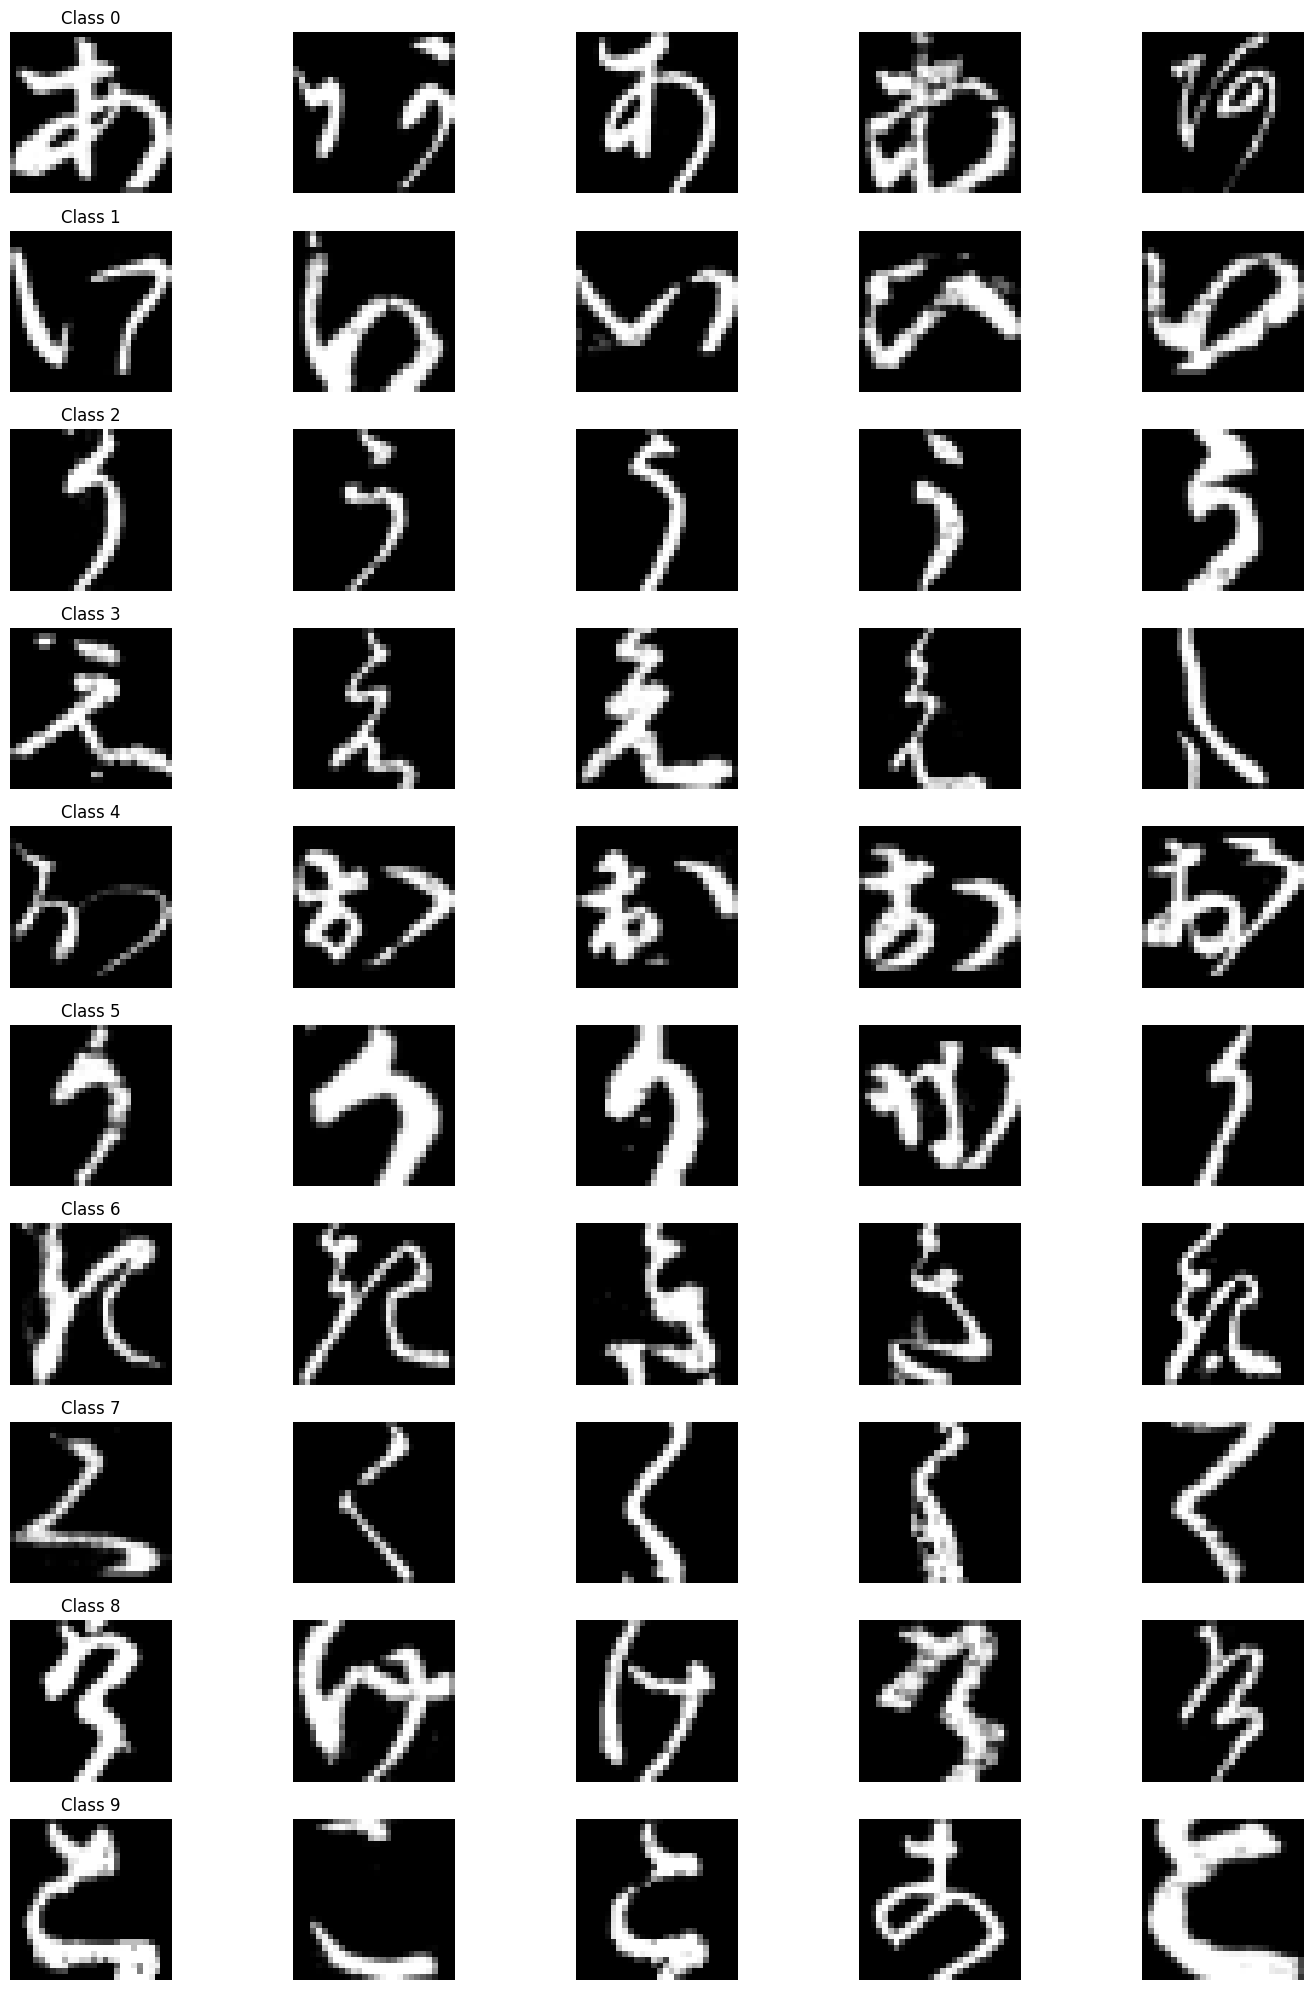

In [3]:
plot_class_distribution(y_images)
analyze_image_statistics(X_images)
plot_class_averages(X_images, y_images, num_classes=15)  # Mostrar las primeras 15 clases
analyze_image_complexity(X_images, y_images)
plot_examples_by_class(X_images, y_images, examples_per_class=5)

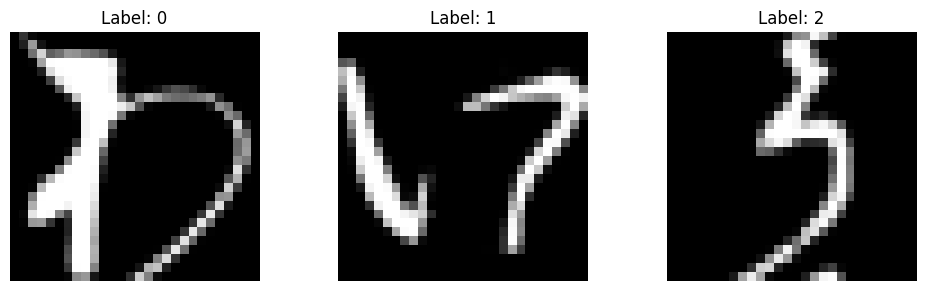

In [4]:
unique_labels = np.unique(y_images)
selected_images = []
selected_labels = []

for label in unique_labels:
    idx = np.where(y_images == label)[0][0]
    selected_images.append(X_images[idx].reshape(28, 28))
    selected_labels.append(label)
    if len(selected_images) == 3:
        break

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(selected_images[i], cmap='gray')
    ax.set_title(f"Label: {selected_labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

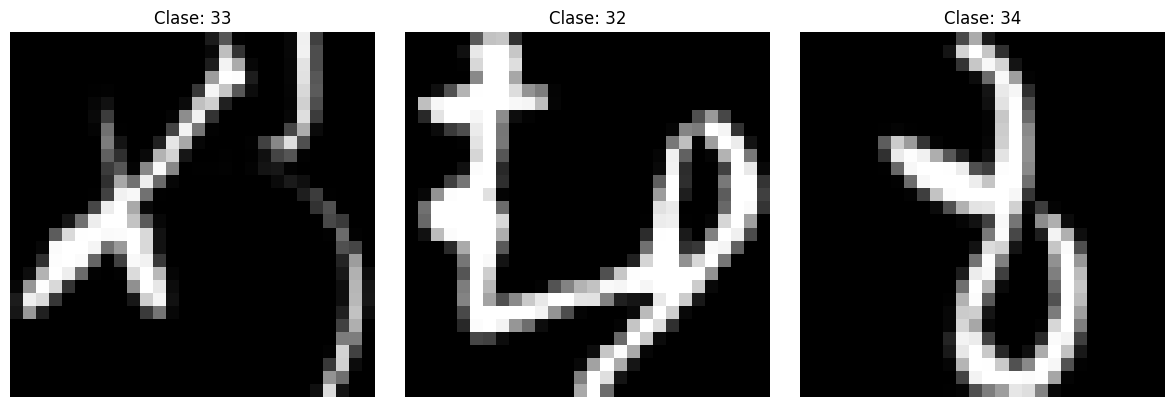

In [5]:
plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    idx = np.random.randint(0, len(X_images))
    img = X_images[idx].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"Clase: {y_images[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(
    X_images / 255.0 , y_images, train_ratio=0.8 * 0.8, val_ratio=0.8 * 0.2, test_ratio=0.2, random_state=42
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"Rango de valores en X_train: [{X_train.min()}, {X_train.max()}]")

X_train: (3197, 784), y_train: (3197,)
X_val: (802, 784), y_val: (802,)
X_test: (1001, 784), y_test: (1001,)
Rango de valores en X_train: [0.0, 1.0]


### 2. Implementación y Entrenamiento de una Red Neuronal Básica
- Implementar una red neuronal con L capas ocultas cada con M (l) nodos con
función de activación ReLU (en las capas ocultas) y activación softmax para la
capa de salida.
- Implementar un algoritmo para entrenar dicha red, mediante backpropagation y
gradiente descendiente estándar, utilizando como función de costo la cross-entropy.
NOTA: El algoritmo backpropagation debe sera adaptado para el caso de clasi-
ficación multi-clase con función de activación softmax para la capa de salida y
función de costo cross-entropy.
- Entrenar una red neuronal con 2 capas ocultas, con 100 y 80 nodos respectiva-
mente, y graficar la evolución de la función de costo (cross-entropy) sobre los
conjuntos de entrenamiento y validación a lo largo de las épocas. Llamaremos a
este modelo M0.
Reportar las siguientes métricas de performance, sobre los conjuntos de entrena-
miento y validación, para el modelo base entrenado:
    - Accuracy
    - Cross-Entropy 
    - Matriz de Confusión

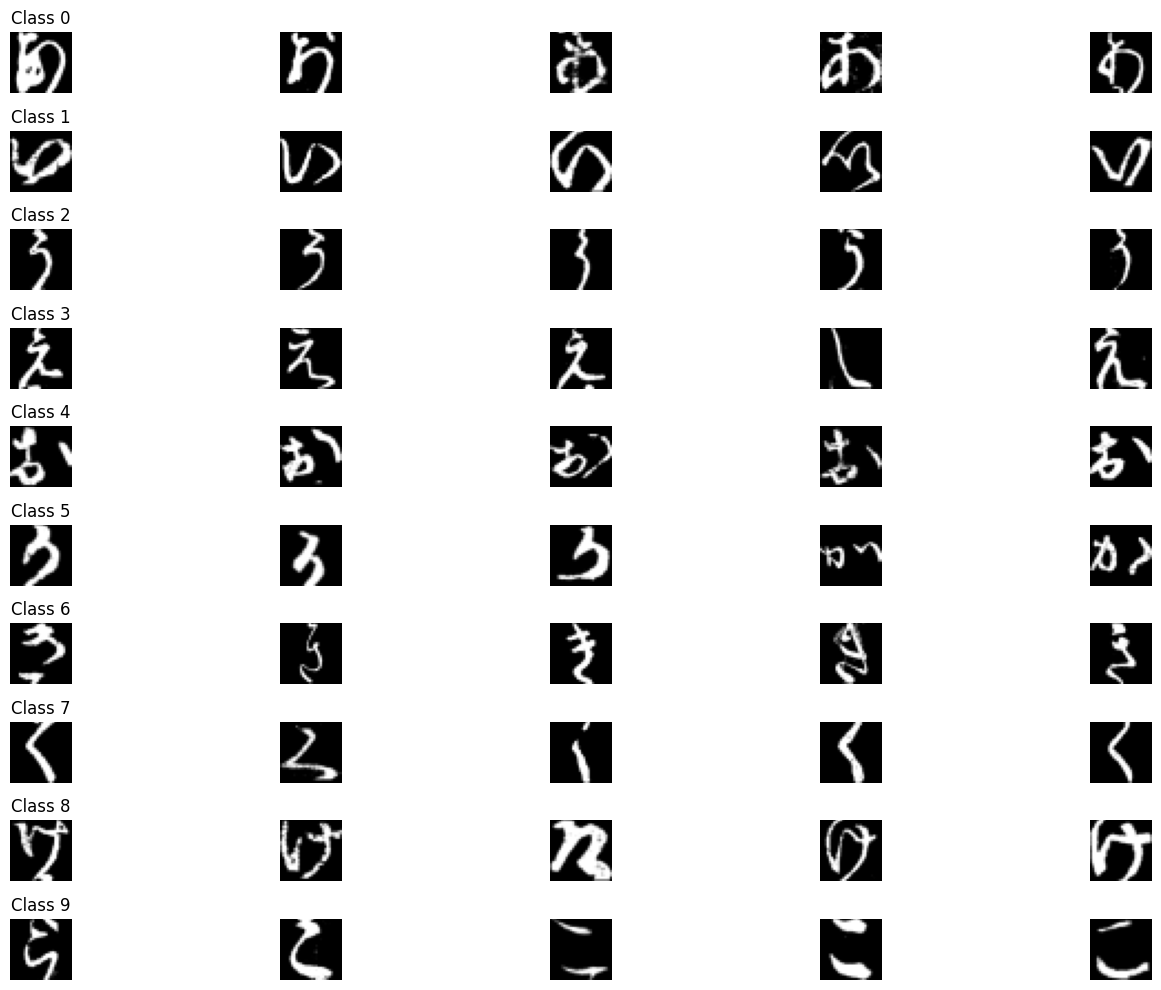

Epoch 1/50: train_loss=4.0434, train_acc=0.0222, val_loss=4.0294, val_acc=0.0224
Epoch 2/50: train_loss=4.0370, train_acc=0.0225, val_loss=4.0235, val_acc=0.0212
Epoch 3/50: train_loss=4.0310, train_acc=0.0222, val_loss=4.0179, val_acc=0.0212
Epoch 4/50: train_loss=4.0252, train_acc=0.0225, val_loss=4.0127, val_acc=0.0224
Epoch 5/50: train_loss=4.0198, train_acc=0.0231, val_loss=4.0077, val_acc=0.0212
Epoch 6/50: train_loss=4.0146, train_acc=0.0225, val_loss=4.0029, val_acc=0.0212
Epoch 7/50: train_loss=4.0097, train_acc=0.0225, val_loss=3.9984, val_acc=0.0200
Epoch 8/50: train_loss=4.0050, train_acc=0.0225, val_loss=3.9942, val_acc=0.0200
Epoch 9/50: train_loss=4.0005, train_acc=0.0225, val_loss=3.9901, val_acc=0.0200
Epoch 10/50: train_loss=3.9962, train_acc=0.0228, val_loss=3.9861, val_acc=0.0200
Epoch 11/50: train_loss=3.9921, train_acc=0.0225, val_loss=3.9824, val_acc=0.0200
Epoch 12/50: train_loss=3.9881, train_acc=0.0228, val_loss=3.9787, val_acc=0.0200
Epoch 13/50: train_loss=3

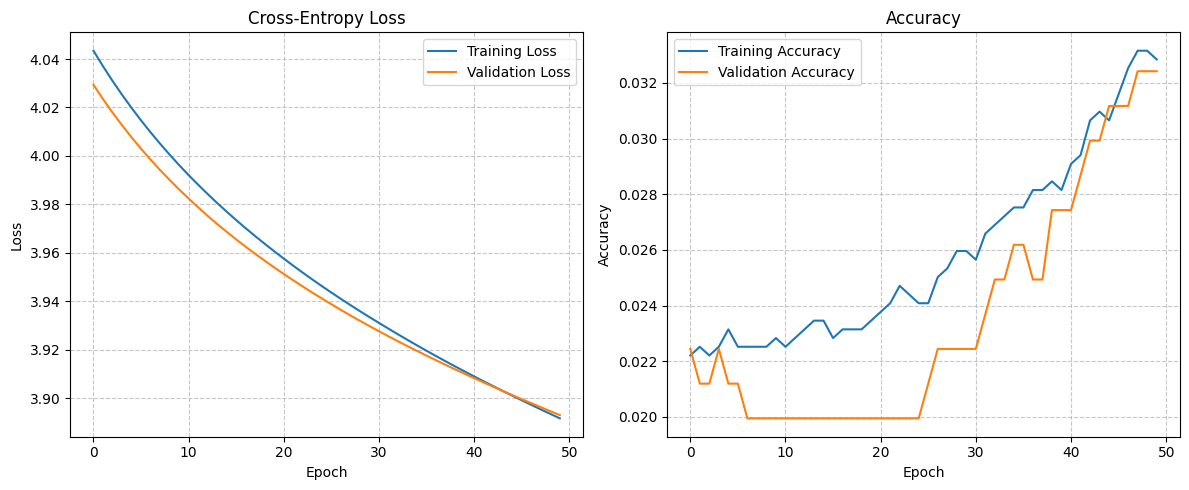

Performance Metrics for Model M0:
Training Set - Accuracy: 0.0332, Cross-Entropy: 3.8899
Validation Set - Accuracy: 0.0324, Cross-Entropy: 3.8930


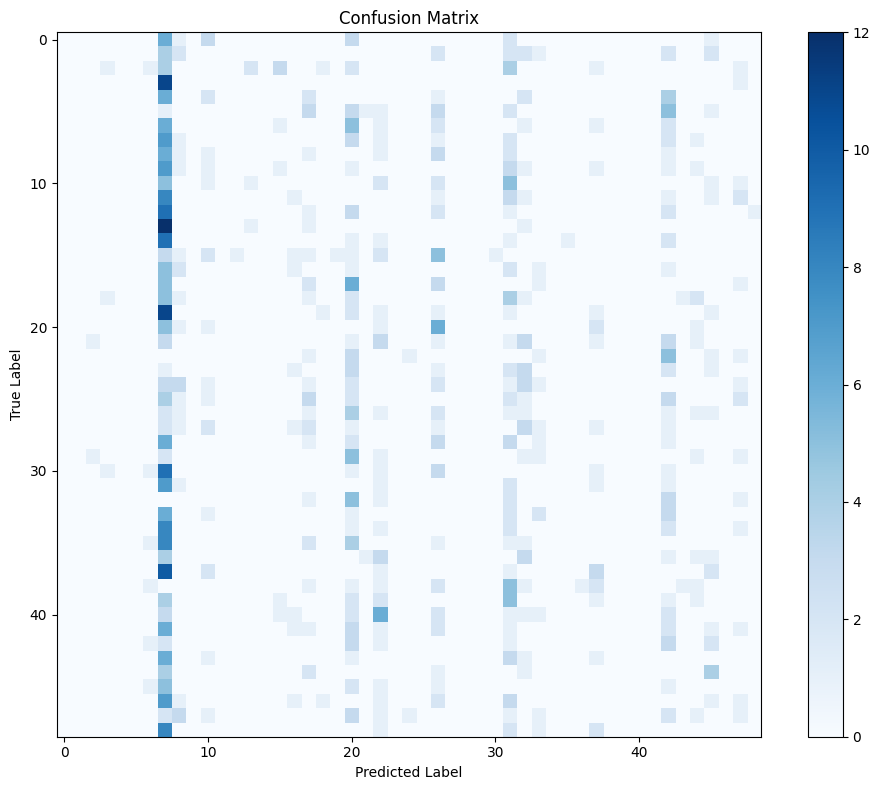

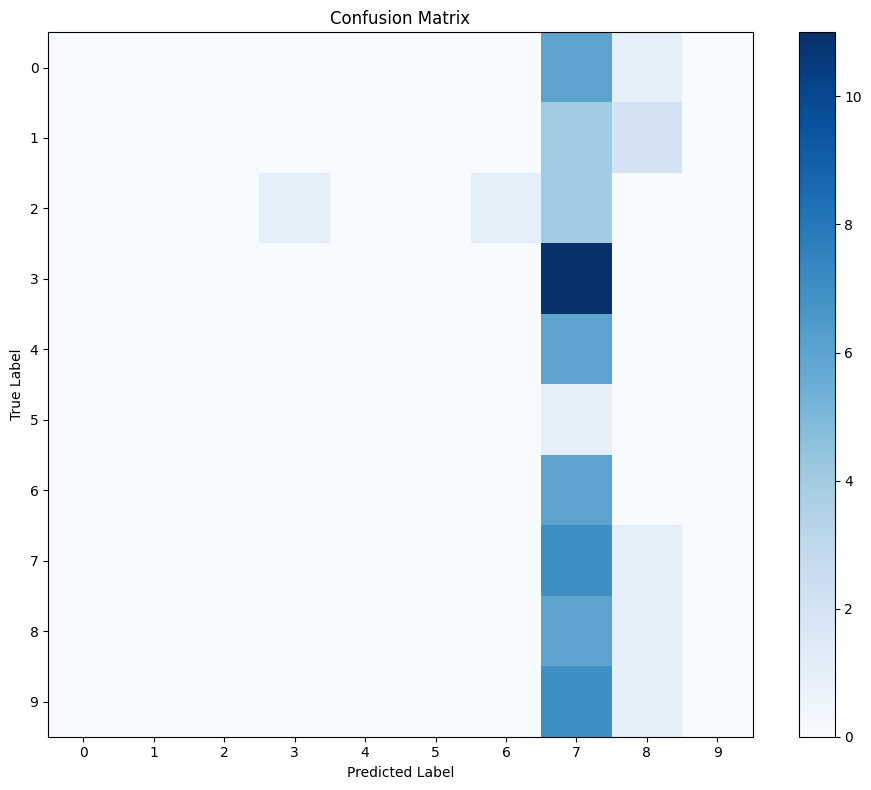

In [ ]:
# Display some examples from the dataset
visualize_samples(X_train, y_train, num_samples=5, num_classes=10)

# Create a neural network with 2 hidden layers (100 and 80 nodes)
input_size = X_train.shape[1]  # 784 for 28x28 images
output_size = len(np.unique(y_train))  # Number of classes (49)
layer_sizes = [input_size, 100, 80, output_size]

# Initialize the model (Model M0)
model_M0 = NeuralNetwork(layer_sizes, learning_rate=0.01)

# Train the model
history_M0 = model_M0.train(X_train, y_train, X_val, y_val, epochs=50)

# Plot learning curves
plot_learning_curves(history_M0)

# Evaluate the model on training and validation sets
train_pred = model_M0.forward(X_train)
val_pred = model_M0.forward(X_val)

train_loss = model_M0.cross_entropy_loss(y_train, train_pred)
val_loss = model_M0.cross_entropy_loss(y_val, val_pred)

train_accuracy = model_M0.accuracy(y_train, train_pred)
val_accuracy = model_M0.accuracy(y_val, val_pred)

print(f"Performance Metrics for Model M0:")
print(f"Training Set - Accuracy: {train_accuracy:.4f}, Cross-Entropy: {train_loss:.4f}")
print(f"Validation Set - Accuracy: {val_accuracy:.4f}, Cross-Entropy: {val_loss:.4f}")

# Compute and plot confusion matrix for validation set
conf_matrix = model_M0.confusion_matrix(y_val, val_pred)
plot_confusion_matrix(conf_matrix)

# Since the full confusion matrix might be too large (49x49), 
# let's also look at a subset of classes
plot_confusion_matrix(conf_matrix, class_subset=list(range(10)))  # First 10 classes